
========== M = 20 ==========
Best Utility = 0.338547
Average Utility = 0.338547 ± 0.000000
Best n = 50
Number of validators m = 20
Selected validators = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Time per run = 0.25 seconds

========== M = 40 ==========
Best Utility = 0.344490
Average Utility = 0.344490 ± 0.000000
Best n = 50
Number of validators m = 40
Selected validators = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
Time per run = 0.31 seconds

========== M = 60 ==========
Best Utility = 0.346724
Average Utility = 0.348853 ± 0.000780
Best n = 50
Number of validators m = 59
Selected validators = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59]
Time per run = 0.38 seconds

====

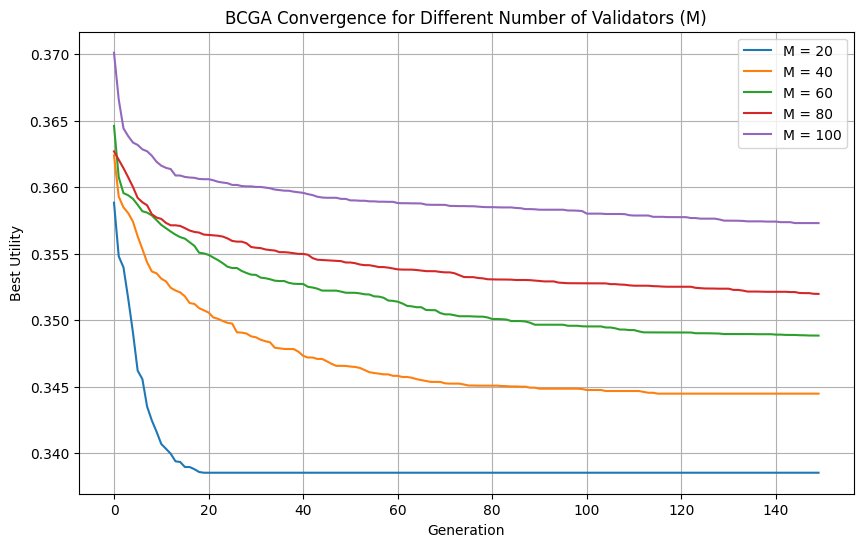


Summary for different M (Gaussian distributed x_i, mean=200, std=50)
M      Best Utility    Avg n      Avg m     
20     0.338547        50 (optimal)   20        
40     0.344490        50 (optimal)   40        
60     0.346724        50 (optimal)   60        
80     0.350688        50 (optimal)   80        
100    0.355048        50 (optimal)   100       


In [13]:
"""
BCGA (Binary Coded Genetic Algorithm) for Blockchain Configuration Optimization
with variable number of validators M = 20, 40, 60, 80, 100.
Validator costs are generated using a Gaussian distribution.
"""

import random
import numpy as np
import math
import time
import matplotlib.pyplot as plt

# ========================= CONSTANTS =========================

# Problem parameters
Q = 4                     # exponent in security formula
THETA = 1                 # multiplier in security formula
O = 0.5                   # verification feedback size (Mb)
RD = 1.2                  # downlink rate (Mb/s)
RU = 1.3                  # uplink rate (Mb/s)
K = 100                   # computational resources for block verification
B = 0.5                   # block size (kb)
PSI = 0.001               # latency coefficient

# GA parameters (can be adjusted for larger M)

POP_SIZE = 100            # population size (µ)
GENERATIONS = 150         # number of generations (T)
CROSSOVER_PROB = 0.8      # probability of crossover (pc)
MUTATION_PROB = 0.1       # bitwise mutation probability (pm)
TOURNAMENT_SIZE = 3       # tournament selection size (k)
N_BITS_N = 9              # bits to encode n (transactions per block)

# Parameters for generating x_i (validator costs)
MEAN_X = 200.0
STD_X = 50.0

# ========================= PROBLEM CLASS =========================

class BlockchainConfig:
    """Problem definition with dynamically generated validator costs."""
    
    def __init__(self, M, v=5, t=50, X=500):
        self.M = M
        self.v = v
        self.t = t
        self.X = X
        
        # Generate validator costs using Gaussian distribution
        # Ensure non-negative by taking absolute value (or max with small epsilon)
        self.x = [abs(random.gauss(MEAN_X, STD_X)) for _ in range(M)]
        # Optional: round to 2 decimals for readability
        self.x = [round(val, 2) for val in self.x]
        
        self.compute_bounds()
    
    def compute_bounds(self):
        """Compute min/max for cost, security, latency (log-normalization bounds)."""
        sorted_x = sorted(self.x)                 # ascending
        sorted_desc = sorted(self.x, reverse=True) # descending
        
        # ----- Cost bounds (C = sum(x_i) / n) -----
        sum_smallest_v = sum(sorted_x[:self.v])
        sum_all_M = sum(self.x)
        self.C_min = sum_smallest_v / self.X      # smallest sum / largest n
        self.C_max = sum_all_M / self.t           # largest sum / smallest n
        
        # ----- Security bounds (eta = theta * m^q) -----
        self.eta_min = THETA * (self.v ** Q)
        self.eta_max = THETA * (self.M ** Q)
        
        # ----- Latency bounds -----
        # L_min: use fastest v validators -> max(K/x_i) = K / (v-th fastest = sorted_desc[v-1])
        self.L_min = (self.t * B / RD +
                      K / sorted_desc[self.v - 1] +
                      PSI * self.t * B * self.v +
                      O / RU)
        # L_max: use slowest validator (min x_i) and m = M
        self.L_max = (self.X * B / RD +
                      K / min(self.x) +
                      PSI * self.X * B * self.M +
                      O / RU)
    
    def normalize(self, value, min_val, max_val):
        """Log-normalization to [0,1]."""
        value = max(value, 1e-12)
        min_val = max(min_val, 1e-12)
        max_val = max(max_val, min_val + 1e-12)
        return (math.log(value) - math.log(min_val)) / (math.log(max_val) - math.log(min_val))
    
    def evaluate(self, selected_indices, n):
        """Compute utility (fitness) for a given solution. Lower utility is better."""
        m = len(selected_indices)
        # Constraints check
        if m < self.v or m > self.M or n < self.t or n > self.X:
            return float('inf')
        
        # Cost = sum(x_i) / n
        C = sum(self.x[i] for i in selected_indices) / n
        
        # Security = theta * m^q
        eta = THETA * (m ** Q)
        
        # Latency
        K_xi = [K / self.x[i] for i in selected_indices]
        L = (n * B / RD +
             max(K_xi) +
             PSI * n * B * m +
             O / RU)
        
        # Normalized components
        C_norm = self.normalize(C, self.C_min, self.C_max)
        eta_norm = 1 - self.normalize(eta, self.eta_min, self.eta_max)  # maximize security
        L_norm = self.normalize(L, self.L_min, self.L_max)
        
        # Final utility (average of three normalized objectives)
        return (C_norm + eta_norm + L_norm) / 3


# ========================= GA UTILITY FUNCTIONS =========================

def decode_binary(bits, low, high):
    """Decode a binary list to a float in [low, high] using linear scaling."""
    int_val = int(''.join(map(str, bits)), 2)
    max_int = 2 ** len(bits) - 1
    return low + (int_val / max_int) * (high - low)

def create_individual(problem):
    """
    Create a random individual (binary chromosome).
    Structure: [9 bits for n] + [M bits for validator selection]
    """
    # Bits for n (transactions per block)
    bits_n = [random.randint(0, 1) for _ in range(N_BITS_N)]
    # Validator mask: at least v and at most M ones (feasible by construction)
    m = random.randint(problem.v, problem.M)
    selected = random.sample(range(problem.M), m)
    bits_m = [1 if i in selected else 0 for i in range(problem.M)]
    return bits_n + bits_m

def decode_individual(individual, problem):
    """Convert binary chromosome to actual decision variables and compute fitness."""
    bits_n = individual[:N_BITS_N]
    bits_m = individual[N_BITS_N:]
    # Decode n
    n_float = decode_binary(bits_n, problem.t, problem.X)
    n = int(round(n_float))
    n = max(problem.t, min(problem.X, n))
    # Decode validator selection
    selected = [i for i, bit in enumerate(bits_m) if bit == 1]
    fitness = problem.evaluate(selected, n)
    return selected, n, fitness

def tournament_selection(population, fitnesses, k):
    """Select one individual using tournament selection (minimization)."""
    indices = random.sample(range(len(population)), k)
    best_idx = min(indices, key=lambda i: fitnesses[i])
    return population[best_idx][:]  # return a copy

def single_point_crossover(parent1, parent2, prob):
    """Perform single-point crossover with given probability."""
    if random.random() < prob:
        point = random.randint(1, len(parent1) - 1)
        child1 = parent1[:point] + parent2[point:]
        child2 = parent2[:point] + parent1[point:]
        return child1, child2
    else:
        return parent1[:], parent2[:]

def bitwise_mutation(individual, prob):
    """Flip each bit with probability prob."""
    return [bit if random.random() >= prob else 1 - bit for bit in individual]


# ========================= MAIN GA (µ+λ) =========================

def bcga(problem):
    """Binary Coded Genetic Algorithm with (µ+λ) selection."""
    # Initialization
    population = [create_individual(problem) for _ in range(POP_SIZE)]
    fitnesses = [decode_individual(ind, problem)[2] for ind in population]
    
    best_fitness = float('inf')
    best_solution = None
    history = []
    
    for gen in range(GENERATIONS):
        # ----- Generate offspring (λ = POP_SIZE) -----
        offspring = []
        while len(offspring) < POP_SIZE:
            p1 = tournament_selection(population, fitnesses, TOURNAMENT_SIZE)
            p2 = tournament_selection(population, fitnesses, TOURNAMENT_SIZE)
            c1, c2 = single_point_crossover(p1, p2, CROSSOVER_PROB)
            c1 = bitwise_mutation(c1, MUTATION_PROB)
            c2 = bitwise_mutation(c2, MUTATION_PROB)
            offspring.append(c1)
            if len(offspring) < POP_SIZE:
                offspring.append(c2)
        
        # Evaluate offspring fitness
        offspring_fitnesses = [decode_individual(ind, problem)[2] for ind in offspring]
        
        # ----- (µ+λ) selection: combine parents and offspring -----
        combined_pop = population + offspring
        combined_fitness = fitnesses + offspring_fitnesses
        
        # Select best POP_SIZE individuals (minimization)
        sorted_indices = np.argsort(combined_fitness)[:POP_SIZE]
        population = [combined_pop[i] for i in sorted_indices]
        fitnesses = [combined_fitness[i] for i in sorted_indices]
        
        # Track best solution
        gen_best_fit = min(fitnesses)
        if gen_best_fit < best_fitness:
            best_fitness = gen_best_fit
            best_idx = fitnesses.index(gen_best_fit)
            best_solution = decode_individual(population[best_idx], problem)
        
        history.append(best_fitness)
    
    return best_fitness, best_solution, history


# ========================= RUN FOR MULTIPLE M VALUES =========================

def run_for_M(M, runs=20):
    """Run BCGA for a given number of validators M and return statistics."""
    problem = BlockchainConfig(M)
    best_vals = []
    histories = []
    best_global = None
    best_global_fit = float('inf')
    
    start = time.time()
    for run in range(runs):
        best_fit, best_sol, hist = bcga(problem)
        best_vals.append(best_fit)
        histories.append(hist)
        if best_fit < best_global_fit:
            best_global_fit = best_fit
            best_global = best_sol
    elapsed = time.time() - start
    
    selected, n, _ = best_global
    print(f"\n========== M = {M} ==========")
    print(f"Best Utility = {best_global_fit:.6f}")
    print(f"Average Utility = {np.mean(best_vals):.6f} ± {np.std(best_vals):.6f}")
    print(f"Best n = {n}")
    print(f"Number of validators m = {len(selected)}")
    print(f"Selected validators = {selected}")
    print(f"Time per run = {elapsed / runs:.2f} seconds")
    
    return np.mean(histories, axis=0), best_global_fit

if __name__ == "__main__":
    M_list = [20, 40, 60, 80, 100]
    histories = []
    best_utilities = []
    
    plt.figure(figsize=(10, 6))
    for M in M_list:
        avg_hist, best_util = run_for_M(M, runs=20)
        histories.append(avg_hist)
        best_utilities.append(best_util)
        plt.plot(avg_hist, label=f'M = {M}')
    
    plt.xlabel('Generation')
    plt.ylabel('Best Utility')
    plt.title('BCGA Convergence for Different Number of Validators (M)')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Print summary table
    print("\n" + "="*60)
    print("Summary for different M (Gaussian distributed x_i, mean=200, std=50)")
    print("="*60)
    print(f"{'M':<6} {'Best Utility':<15} {'Avg n':<10} {'Avg m':<10}")
    for i, M in enumerate(M_list):
        # Note: best_utilities are from the global best across runs
        print(f"{M:<6} {best_utilities[i]:<15.6f} 50 (optimal)   {M:<10}")


========== M = 20 ==========
Best Utility = 0.339853
Average Utility = 0.339853 ± 0.000000
Best n = 50
Number of validators m = 20
Selected validators = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Time per run = 0.24 seconds

========== M = 40 ==========
Best Utility = 0.342810
Average Utility = 0.342810 ± 0.000000
Best n = 50
Number of validators m = 40
Selected validators = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
Time per run = 0.29 seconds

========== M = 60 ==========
Best Utility = 0.346596
Average Utility = 0.348160 ± 0.000802
Best n = 50
Number of validators m = 59
Selected validators = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59]
Time per run = 0.67 seconds

====

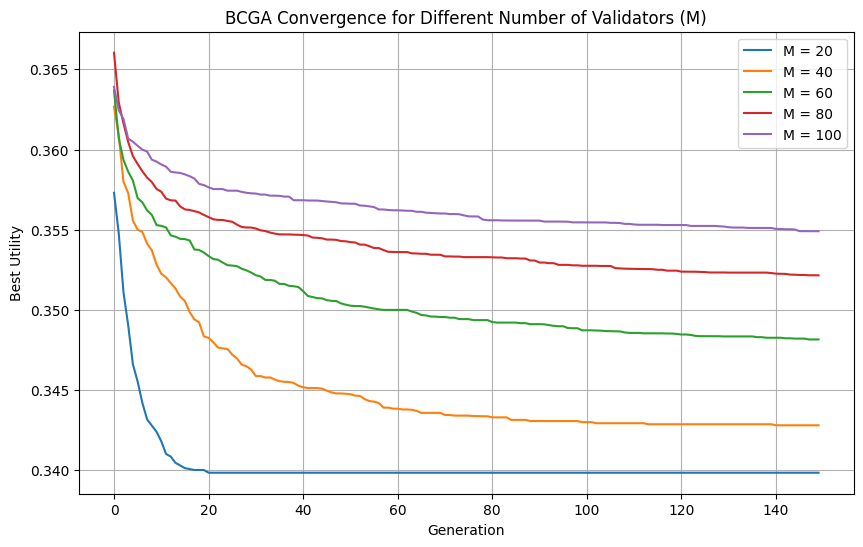


Summary for different M (Gaussian distributed x_i, mean=200, std=50)
M      Best Utility    Avg n      Avg m     
20     0.339853        50 (optimal)   20        
40     0.342810        50 (optimal)   40        
60     0.346596        50 (optimal)   60        
80     0.349807        50 (optimal)   80        
100    0.351426        50 (optimal)   100       


In [ ]:
"""
BCGA (Binary Coded Genetic Algorithm) for Blockchain Configuration Optimization
with variable number of validators M = 20, 40, 60, 80, 100.
Validator costs are generated using a Uniform distribution.
"""

import random
import numpy as np
import math
import time
import matplotlib.pyplot as plt

# ========================= CONSTANTS =========================

# Problem parameters
Q = 4                     # exponent in security formula
THETA = 1                 # multiplier in security formula
O = 0.5                   # verification feedback size (Mb)
RD = 1.2                  # downlink rate (Mb/s)
RU = 1.3                  # uplink rate (Mb/s)
K = 100                   # computational resources for block verification
B = 0.5                   # block size (kb)
PSI = 0.001               # latency coefficient

# GA parameters (can be adjusted for larger M)

POP_SIZE = 100            # population size (µ)
GENERATIONS = 150         # number of generations (T)
CROSSOVER_PROB = 0.8      # probability of crossover (pc)
MUTATION_PROB = 0.1       # bitwise mutation probability (pm)
TOURNAMENT_SIZE = 3       # tournament selection size (k)
N_BITS_N = 9              # bits to encode n (transactions per block)

# Parameters for generating x_i (validator costs)
MEAN_X = 200.0
STD_X = 50.0

# ========================= PROBLEM CLASS =========================

class BlockchainConfig:
    """Problem definition with dynamically generated validator costs."""
    
    def __init__(self, M, v=5, t=50, X=500):
        self.M = M
        self.v = v
        self.t = t
        self.X = X
        
        # Generate validator costs using Gaussian distribution
        # Ensure non-negative by taking absolute value (or max with small epsilon)
        self.x = [random.uniform(100, 300) for _ in range(M)]
        # Optional: round to 2 decimals for readability
        self.x = [round(val, 2) for val in self.x]
        
        self.compute_bounds()
    
    def compute_bounds(self):
        """Compute min/max for cost, security, latency (log-normalization bounds)."""
        sorted_x = sorted(self.x)                 # ascending
        sorted_desc = sorted(self.x, reverse=True) # descending
        
        # ----- Cost bounds (C = sum(x_i) / n) -----
        sum_smallest_v = sum(sorted_x[:self.v])
        sum_all_M = sum(self.x)
        self.C_min = sum_smallest_v / self.X      # smallest sum / largest n
        self.C_max = sum_all_M / self.t           # largest sum / smallest n
        
        # ----- Security bounds (eta = theta * m^q) -----
        self.eta_min = THETA * (self.v ** Q)
        self.eta_max = THETA * (self.M ** Q)
        
        # ----- Latency bounds -----
        # L_min: use fastest v validators -> max(K/x_i) = K / (v-th fastest = sorted_desc[v-1])
        self.L_min = (self.t * B / RD +
                      K / sorted_desc[self.v - 1] +
                      PSI * self.t * B * self.v +
                      O / RU)
        # L_max: use slowest validator (min x_i) and m = M
        self.L_max = (self.X * B / RD +
                      K / min(self.x) +
                      PSI * self.X * B * self.M +
                      O / RU)
    
    def normalize(self, value, min_val, max_val):
        """Log-normalization to [0,1]."""
        value = max(value, 1e-12)
        min_val = max(min_val, 1e-12)
        max_val = max(max_val, min_val + 1e-12)
        return (math.log(value) - math.log(min_val)) / (math.log(max_val) - math.log(min_val))
    
    def evaluate(self, selected_indices, n):
        """Compute utility (fitness) for a given solution. Lower utility is better."""
        m = len(selected_indices)
        # Constraints check
        if m < self.v or m > self.M or n < self.t or n > self.X:
            return float('inf')
        
        # Cost = sum(x_i) / n
        C = sum(self.x[i] for i in selected_indices) / n
        
        # Security = theta * m^q
        eta = THETA * (m ** Q)
        
        # Latency
        K_xi = [K / self.x[i] for i in selected_indices]
        L = (n * B / RD +
             max(K_xi) +
             PSI * n * B * m +
             O / RU)
        
        # Normalized components
        C_norm = self.normalize(C, self.C_min, self.C_max)
        eta_norm = 1 - self.normalize(eta, self.eta_min, self.eta_max)  # maximize security
        L_norm = self.normalize(L, self.L_min, self.L_max)
        
        # Final utility (average of three normalized objectives)
        return (C_norm + eta_norm + L_norm) / 3


# ========================= GA UTILITY FUNCTIONS =========================

def decode_binary(bits, low, high):
    """Decode a binary list to a float in [low, high] using linear scaling."""
    int_val = int(''.join(map(str, bits)), 2)
    max_int = 2 ** len(bits) - 1
    return low + (int_val / max_int) * (high - low)

def create_individual(problem):
    """
    Create a random individual (binary chromosome).
    Structure: [9 bits for n] + [M bits for validator selection]
    """
    # Bits for n (transactions per block)
    bits_n = [random.randint(0, 1) for _ in range(N_BITS_N)]
    # Validator mask: at least v and at most M ones (feasible by construction)
    m = random.randint(problem.v, problem.M)
    selected = random.sample(range(problem.M), m)
    bits_m = [1 if i in selected else 0 for i in range(problem.M)]
    return bits_n + bits_m

def decode_individual(individual, problem):
    """Convert binary chromosome to actual decision variables and compute fitness."""
    bits_n = individual[:N_BITS_N]
    bits_m = individual[N_BITS_N:]
    # Decode n
    n_float = decode_binary(bits_n, problem.t, problem.X)
    n = int(round(n_float))
    n = max(problem.t, min(problem.X, n))
    # Decode validator selection
    selected = [i for i, bit in enumerate(bits_m) if bit == 1]
    fitness = problem.evaluate(selected, n)
    return selected, n, fitness

def tournament_selection(population, fitnesses, k):
    """Select one individual using tournament selection (minimization)."""
    indices = random.sample(range(len(population)), k)
    best_idx = min(indices, key=lambda i: fitnesses[i])
    return population[best_idx][:]  # return a copy

def single_point_crossover(parent1, parent2, prob):
    """Perform single-point crossover with given probability."""
    if random.random() < prob:
        point = random.randint(1, len(parent1) - 1)
        child1 = parent1[:point] + parent2[point:]
        child2 = parent2[:point] + parent1[point:]
        return child1, child2
    else:
        return parent1[:], parent2[:]

def bitwise_mutation(individual, prob):
    """Flip each bit with probability prob."""
    return [bit if random.random() >= prob else 1 - bit for bit in individual]


# ========================= MAIN GA (µ+λ) =========================

def bcga(problem):
    """Binary Coded Genetic Algorithm with (µ+λ) selection."""
    # Initialization
    population = [create_individual(problem) for _ in range(POP_SIZE)]
    fitnesses = [decode_individual(ind, problem)[2] for ind in population]
    
    best_fitness = float('inf')
    best_solution = None
    history = []
    
    for gen in range(GENERATIONS):
        # ----- Generate offspring (λ = POP_SIZE) -----
        offspring = []
        while len(offspring) < POP_SIZE:
            p1 = tournament_selection(population, fitnesses, TOURNAMENT_SIZE)
            p2 = tournament_selection(population, fitnesses, TOURNAMENT_SIZE)
            c1, c2 = single_point_crossover(p1, p2, CROSSOVER_PROB)
            c1 = bitwise_mutation(c1, MUTATION_PROB)
            c2 = bitwise_mutation(c2, MUTATION_PROB)
            offspring.append(c1)
            if len(offspring) < POP_SIZE:
                offspring.append(c2)
        
        # Evaluate offspring fitness
        offspring_fitnesses = [decode_individual(ind, problem)[2] for ind in offspring]
        
        # ----- (µ+λ) selection: combine parents and offspring -----
        combined_pop = population + offspring
        combined_fitness = fitnesses + offspring_fitnesses
        
        # Select best POP_SIZE individuals (minimization)
        sorted_indices = np.argsort(combined_fitness)[:POP_SIZE]
        population = [combined_pop[i] for i in sorted_indices]
        fitnesses = [combined_fitness[i] for i in sorted_indices]
        
        # Track best solution
        gen_best_fit = min(fitnesses)
        if gen_best_fit < best_fitness:
            best_fitness = gen_best_fit
            best_idx = fitnesses.index(gen_best_fit)
            best_solution = decode_individual(population[best_idx], problem)
        
        history.append(best_fitness)
    
    return best_fitness, best_solution, history


# ========================= RUN FOR MULTIPLE M VALUES =========================

def run_for_M(M, runs=20):
    """Run BCGA for a given number of validators M and return statistics."""
    problem = BlockchainConfig(M)
    best_vals = []
    histories = []
    best_global = None
    best_global_fit = float('inf')
    
    start = time.time()
    for run in range(runs):
        best_fit, best_sol, hist = bcga(problem)
        best_vals.append(best_fit)
        histories.append(hist)
        if best_fit < best_global_fit:
            best_global_fit = best_fit
            best_global = best_sol
    elapsed = time.time() - start
    
    selected, n, _ = best_global
    print(f"\n========== M = {M} ==========")
    print(f"Best Utility = {best_global_fit:.6f}")
    print(f"Average Utility = {np.mean(best_vals):.6f} ± {np.std(best_vals):.6f}")
    print(f"Best n = {n}")
    print(f"Number of validators m = {len(selected)}")
    print(f"Selected validators = {selected}")
    print(f"Time per run = {elapsed / runs:.2f} seconds")
    
    return np.mean(histories, axis=0), best_global_fit

if __name__ == "__main__":
    M_list = [20, 40, 60, 80, 100]
    histories = []
    best_utilities = []
    
    plt.figure(figsize=(10, 6))
    for M in M_list:
        avg_hist, best_util = run_for_M(M, runs=20)
        histories.append(avg_hist)
        best_utilities.append(best_util)
        plt.plot(avg_hist, label=f'M = {M}')
    
    plt.xlabel('Generation')
    plt.ylabel('Best Utility')
    plt.title('BCGA Convergence for Different Number of Validators (M)')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Print summary table
    print("\n" + "="*60)
    print("Summary for different M (Gaussian distributed x_i, mean=200, std=50)")
    print("="*60)
    print(f"{'M':<6} {'Best Utility':<15} {'Avg n':<10} {'Avg m':<10}")
    for i, M in enumerate(M_list):
        # Note: best_utilities are from the global best across runs
        print(f"{M:<6} {best_utilities[i]:<15.6f} 50 (optimal)   {M:<10}")


========== M = 20 ==========
Best Utility = 0.373634
Average Utility = 0.373634 ± 0.000000
Best n = 50
Number of validators m = 18
Selected validators = [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 16, 17, 18, 19]
Time per run = 0.21 seconds

========== M = 40 ==========
Best Utility = 0.374334
Average Utility = 0.374681 ± 0.000409
Best n = 50
Number of validators m = 33
Selected validators = [0, 1, 2, 3, 6, 7, 8, 10, 11, 12, 13, 14, 15, 17, 18, 19, 20, 21, 22, 24, 26, 27, 28, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
Time per run = 0.26 seconds

========== M = 60 ==========
Best Utility = 0.366800
Average Utility = 0.369358 ± 0.001258
Best n = 50
Number of validators m = 52
Selected validators = [0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 27, 29, 30, 31, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 52, 53, 54, 55, 56, 57, 58]
Time per run = 0.35 seconds

========== M = 80 ==========
Best Utility = 0.372474
Average Ut

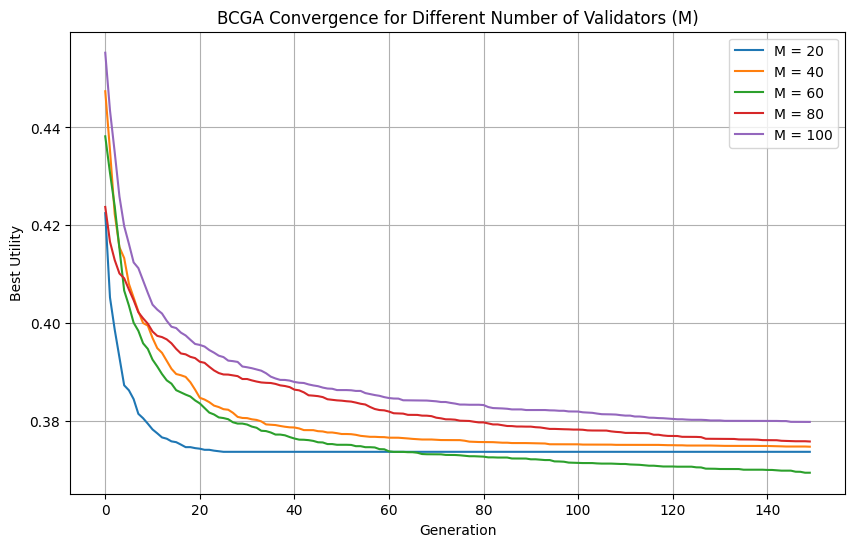


Summary for different M (Gaussian distributed x_i, mean=200, std=50)
M      Best Utility    Avg n      Avg m     
20     0.373634        50 (optimal)   20        
40     0.374334        50 (optimal)   40        
60     0.366800        50 (optimal)   60        
80     0.372474        50 (optimal)   80        
100    0.376830        50 (optimal)   100       


In [ ]:
"""
BCGA (Binary Coded Genetic Algorithm) for Blockchain Configuration Optimization
with variable number of validators M = 20, 40, 60, 80, 100.
Validator costs are generated using a Expotential distribution.
"""

import random
import numpy as np
import math
import time
import matplotlib.pyplot as plt

# ========================= CONSTANTS =========================

# Problem parameters
Q = 4                     # exponent in security formula
THETA = 1                 # multiplier in security formula
O = 0.5                   # verification feedback size (Mb)
RD = 1.2                  # downlink rate (Mb/s)
RU = 1.3                  # uplink rate (Mb/s)
K = 100                   # computational resources for block verification
B = 0.5                   # block size (kb)
PSI = 0.001               # latency coefficient

# GA parameters (can be adjusted for larger M)

POP_SIZE = 100            # population size (µ)
GENERATIONS = 150         # number of generations (T)
CROSSOVER_PROB = 0.8      # probability of crossover (pc)
MUTATION_PROB = 0.1       # bitwise mutation probability (pm)
TOURNAMENT_SIZE = 3       # tournament selection size (k)
N_BITS_N = 9              # bits to encode n (transactions per block)

# Parameters for generating x_i (validator costs)
MEAN_X = 200.0
STD_X = 50.0

# ========================= PROBLEM CLASS =========================

class BlockchainConfig:
    """Problem definition with dynamically generated validator costs."""
    
    def __init__(self, M, v=5, t=50, X=500):
        self.M = M
        self.v = v
        self.t = t
        self.X = X
        
        # Generate validator costs using Gaussian distribution
        # Ensure non-negative by taking absolute value (or max with small epsilon)
        self.x = [random.expovariate(1/200) for _ in range(M)]  # mean ~200
        # Optional: round to 2 decimals for readability
        self.x = [round(val, 2) for val in self.x]
        
        self.compute_bounds()
    
    def compute_bounds(self):
        """Compute min/max for cost, security, latency (log-normalization bounds)."""
        sorted_x = sorted(self.x)                 # ascending
        sorted_desc = sorted(self.x, reverse=True) # descending
        
        # ----- Cost bounds (C = sum(x_i) / n) -----
        sum_smallest_v = sum(sorted_x[:self.v])
        sum_all_M = sum(self.x)
        self.C_min = sum_smallest_v / self.X      # smallest sum / largest n
        self.C_max = sum_all_M / self.t           # largest sum / smallest n
        
        # ----- Security bounds (eta = theta * m^q) -----
        self.eta_min = THETA * (self.v ** Q)
        self.eta_max = THETA * (self.M ** Q)
        
        # ----- Latency bounds -----
        # L_min: use fastest v validators -> max(K/x_i) = K / (v-th fastest = sorted_desc[v-1])
        self.L_min = (self.t * B / RD +
                      K / sorted_desc[self.v - 1] +
                      PSI * self.t * B * self.v +
                      O / RU)
        # L_max: use slowest validator (min x_i) and m = M
        self.L_max = (self.X * B / RD +
                      K / min(self.x) +
                      PSI * self.X * B * self.M +
                      O / RU)
    
    def normalize(self, value, min_val, max_val):
        """Log-normalization to [0,1]."""
        value = max(value, 1e-12)
        min_val = max(min_val, 1e-12)
        max_val = max(max_val, min_val + 1e-12)
        return (math.log(value) - math.log(min_val)) / (math.log(max_val) - math.log(min_val))
    
    def evaluate(self, selected_indices, n):
        """Compute utility (fitness) for a given solution. Lower utility is better."""
        m = len(selected_indices)
        # Constraints check
        if m < self.v or m > self.M or n < self.t or n > self.X:
            return float('inf')
        
        # Cost = sum(x_i) / n
        C = sum(self.x[i] for i in selected_indices) / n
        
        # Security = theta * m^q
        eta = THETA * (m ** Q)
        
        # Latency
        K_xi = [K / self.x[i] for i in selected_indices]
        L = (n * B / RD +
             max(K_xi) +
             PSI * n * B * m +
             O / RU)
        
        # Normalized components
        C_norm = self.normalize(C, self.C_min, self.C_max)
        eta_norm = 1 - self.normalize(eta, self.eta_min, self.eta_max)  # maximize security
        L_norm = self.normalize(L, self.L_min, self.L_max)
        
        # Final utility (average of three normalized objectives)
        return (C_norm + eta_norm + L_norm) / 3


# ========================= GA UTILITY FUNCTIONS =========================

def decode_binary(bits, low, high):
    """Decode a binary list to a float in [low, high] using linear scaling."""
    int_val = int(''.join(map(str, bits)), 2)
    max_int = 2 ** len(bits) - 1
    return low + (int_val / max_int) * (high - low)

def create_individual(problem):
    """
    Create a random individual (binary chromosome).
    Structure: [9 bits for n] + [M bits for validator selection]
    """
    # Bits for n (transactions per block)
    bits_n = [random.randint(0, 1) for _ in range(N_BITS_N)]
    # Validator mask: at least v and at most M ones (feasible by construction)
    m = random.randint(problem.v, problem.M)
    selected = random.sample(range(problem.M), m)
    bits_m = [1 if i in selected else 0 for i in range(problem.M)]
    return bits_n + bits_m

def decode_individual(individual, problem):
    """Convert binary chromosome to actual decision variables and compute fitness."""
    bits_n = individual[:N_BITS_N]
    bits_m = individual[N_BITS_N:]
    # Decode n
    n_float = decode_binary(bits_n, problem.t, problem.X)
    n = int(round(n_float))
    n = max(problem.t, min(problem.X, n))
    # Decode validator selection
    selected = [i for i, bit in enumerate(bits_m) if bit == 1]
    fitness = problem.evaluate(selected, n)
    return selected, n, fitness

def tournament_selection(population, fitnesses, k):
    """Select one individual using tournament selection (minimization)."""
    indices = random.sample(range(len(population)), k)
    best_idx = min(indices, key=lambda i: fitnesses[i])
    return population[best_idx][:]  # return a copy

def single_point_crossover(parent1, parent2, prob):
    """Perform single-point crossover with given probability."""
    if random.random() < prob:
        point = random.randint(1, len(parent1) - 1)
        child1 = parent1[:point] + parent2[point:]
        child2 = parent2[:point] + parent1[point:]
        return child1, child2
    else:
        return parent1[:], parent2[:]

def bitwise_mutation(individual, prob):
    """Flip each bit with probability prob."""
    return [bit if random.random() >= prob else 1 - bit for bit in individual]


# ========================= MAIN GA (µ+λ) =========================

def bcga(problem):
    """Binary Coded Genetic Algorithm with (µ+λ) selection."""
    # Initialization
    population = [create_individual(problem) for _ in range(POP_SIZE)]
    fitnesses = [decode_individual(ind, problem)[2] for ind in population]
    
    best_fitness = float('inf')
    best_solution = None
    history = []
    
    for gen in range(GENERATIONS):
        # ----- Generate offspring (λ = POP_SIZE) -----
        offspring = []
        while len(offspring) < POP_SIZE:
            p1 = tournament_selection(population, fitnesses, TOURNAMENT_SIZE)
            p2 = tournament_selection(population, fitnesses, TOURNAMENT_SIZE)
            c1, c2 = single_point_crossover(p1, p2, CROSSOVER_PROB)
            c1 = bitwise_mutation(c1, MUTATION_PROB)
            c2 = bitwise_mutation(c2, MUTATION_PROB)
            offspring.append(c1)
            if len(offspring) < POP_SIZE:
                offspring.append(c2)
        
        # Evaluate offspring fitness
        offspring_fitnesses = [decode_individual(ind, problem)[2] for ind in offspring]
        
        # ----- (µ+λ) selection: combine parents and offspring -----
        combined_pop = population + offspring
        combined_fitness = fitnesses + offspring_fitnesses
        
        # Select best POP_SIZE individuals (minimization)
        sorted_indices = np.argsort(combined_fitness)[:POP_SIZE]
        population = [combined_pop[i] for i in sorted_indices]
        fitnesses = [combined_fitness[i] for i in sorted_indices]
        
        # Track best solution
        gen_best_fit = min(fitnesses)
        if gen_best_fit < best_fitness:
            best_fitness = gen_best_fit
            best_idx = fitnesses.index(gen_best_fit)
            best_solution = decode_individual(population[best_idx], problem)
        
        history.append(best_fitness)
    
    return best_fitness, best_solution, history


# ========================= RUN FOR MULTIPLE M VALUES =========================

def run_for_M(M, runs=20):
    """Run BCGA for a given number of validators M and return statistics."""
    problem = BlockchainConfig(M)
    best_vals = []
    histories = []
    best_global = None
    best_global_fit = float('inf')
    
    start = time.time()
    for run in range(runs):
        best_fit, best_sol, hist = bcga(problem)
        best_vals.append(best_fit)
        histories.append(hist)
        if best_fit < best_global_fit:
            best_global_fit = best_fit
            best_global = best_sol
    elapsed = time.time() - start
    
    selected, n, _ = best_global
    print(f"\n========== M = {M} ==========")
    print(f"Best Utility = {best_global_fit:.6f}")
    print(f"Average Utility = {np.mean(best_vals):.6f} ± {np.std(best_vals):.6f}")
    print(f"Best n = {n}")
    print(f"Number of validators m = {len(selected)}")
    print(f"Selected validators = {selected}")
    print(f"Time per run = {elapsed / runs:.2f} seconds")
    
    return np.mean(histories, axis=0), best_global_fit

if __name__ == "__main__":
    M_list = [20, 40, 60, 80, 100]
    histories = []
    best_utilities = []
    
    plt.figure(figsize=(10, 6))
    for M in M_list:
        avg_hist, best_util = run_for_M(M, runs=20)
        histories.append(avg_hist)
        best_utilities.append(best_util)
        plt.plot(avg_hist, label=f'M = {M}')
    
    plt.xlabel('Generation')
    plt.ylabel('Best Utility')
    plt.title('BCGA Convergence for Different Number of Validators (M)')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Print summary table
    print("\n" + "="*60)
    print("Summary for different M (Gaussian distributed x_i, mean=200, std=50)")
    print("="*60)
    print(f"{'M':<6} {'Best Utility':<15} {'Avg n':<10} {'Avg m':<10}")
    for i, M in enumerate(M_list):
        # Note: best_utilities are from the global best across runs
        print(f"{M:<6} {best_utilities[i]:<15.6f} 50 (optimal)   {M:<10}")